In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

In [17]:
paper13 = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/Be_stars/Iqbal&Keller_2013.csv')

In [8]:
paper13

,system,cluster,log_age_Myr,radius_arcmin,radius_glatt_arcmin,MSTO_Vmag,cluster_NBe_NB,cluster_NBe_frac,field_NBe_NB,field_NBe_frac,N_field_cont
0,LMC,NGC2004,7.2,1.85,1.45,14.6,19 (22)/207,0.084,42 (43)/827,0.048,4.64
1,LMC,NGC1805,7.6,0.99,0.85,16.0,4/46,0.080,16/463,0.033,0.47
2,LMC,ESO86SC2,7.5,1.18,1.10,15.7,3/35,0.079,12/217,0.052,0.51
3,LMC,NGC2025,8.0,0.95,0.95,17.2,1/18,0.053,21/344,0.058,0.57
4,LMC,LMC0461,8.1,0.76,0.80,17.5,0/10,0.000,10/113,0.081,0.17
5,LMC,NGC1755,7.4,1.17,1.02,15.3,4/81,0.047,17/771,0.022,0.70
6,LMC,NGC1774,7.7,0.76,0.80,16.3,6/45,0.118,10 (11)/447,0.022,0.17
7,LMC,NGC1951,7.7,1.25,0.80,16.3,1/32,0.030,25/378,0.062,0.19
8,LMC,LMC0899,8.1,1.62,0.85,17.5,0/14,0.000,2/89,0.022,0.17
9,LMC,NGC1902,8.0,1.00,0.85,17.2,2/10,0.167,6/181,0.032,0.18


In [29]:
paper13["cluster"] = (
    paper13["cluster"]
    .str.split(",").str[0]      # pega antes da vírgula
    .str.replace("-", "", regex=False)
    .str.replace(" ", "", regex=False)
)

In [19]:
my_frac = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/Be_stars/stellar_clusters_age/be_stars_fraction_per_cluster.csv')

In [63]:
my_frac

,cluster_Names,counts_be_stars,counts_all_stars,fraction_be_stars,[M/H],amaj,Cross-ID,Vmag,e_Vmag,LogAge_total,ra_deg,dec_deg
0,BOB1,3.0,360,0.008333,,3.70,NaN,NaN,NaN,8.20,11.391667,-73.257222
1,BOB11,1.0,376,0.002660,,3.00,NaN,NaN,NaN,,13.537500,-72.710833
2,BOB12,15.0,3543,0.004234,,4.50,NaN,NaN,NaN,7.60,13.841667,-72.782500
3,BOB13,54.0,7138,0.007565,,9.00,NaN,NaN,NaN,6.80,14.491667,-72.548333
4,BOB14,33.0,9597,0.003439,,7.00,NaN,NaN,NaN,6.90,14.908333,-72.747222
...,...,...,...,...,...,...,...,...,...,...,...,...
5563,"ZHTSP2,LOGLE37",0.0,114,0.000000,NaN,0.95,NaN,NaN,NaN,NaN,75.833330,-66.981110
5564,ZHT12,0.0,60,0.000000,NaN,0.65,NaN,NaN,NaN,NaN,79.175000,-67.803060
5565,ZHT2,0.0,112,0.000000,NaN,0.60,NaN,NaN,NaN,NaN,75.620830,-66.610830
5566,"ZHT3,LOGLE88",0.0,135,0.000000,NaN,1.50,NaN,NaN,NaN,NaN,76.475000,-66.733330


In [28]:
my_frac["cluster_Names"] = (
    my_frac["cluster_Names"]
    # .str.split(",").str[0]      # pega antes da vírgula
    .str.replace("-", "", regex=False)
    .str.replace(" ", "", regex=False)
)

In [30]:
import pandas as pd

aliases = (
    my_frac
    .assign(name=my_frac["cluster_Names"].str.split(","))
    .explode("name")
)

aliases["name"] = aliases["name"].str.strip()

In [31]:
comp = paper13.merge(
    aliases,
    left_on="cluster",
    right_on="name",
    how="inner"
)

In [32]:
comp

,system,cluster,log_age_Myr,radius_arcmin,radius_glatt_arcmin,MSTO_Vmag,cluster_NBe_NB,cluster_NBe_frac,field_NBe_NB,field_NBe_frac,...,fraction_be_stars,[M/H],amaj,Cross-ID,Vmag,e_Vmag,LogAge_total,ra_deg,dec_deg,name
0,LMC,NGC2004,7.2,1.85,1.45,14.6,19 (22)/207,0.084,42 (43)/827,0.048,...,0.019923,NaN,3.0,NaN,NaN,NaN,NaN,82.666670,-67.286940,NGC2004
1,LMC,NGC1805,7.6,0.99,0.85,16.0,4/46,0.080,16/463,0.033,...,0.014493,NaN,1.8,NaN,NaN,NaN,NaN,75.587500,-66.111670,NGC1805
2,LMC,NGC2025,8.0,0.95,0.95,17.2,1/18,0.053,21/344,0.058,...,0.004717,NaN,1.9,NaN,NaN,NaN,NaN,83.137500,-71.716940,NGC2025
3,LMC,NGC1755,7.4,1.17,1.02,15.3,4/81,0.047,17/771,0.022,...,0.021480,NaN,2.2,"NGC1755,SL99,ESO56SC28,KMHK272",9.385,0.1,7.400000095367432,73.808330,-68.204720,NGC1755
4,LMC,NGC1774,7.7,0.76,0.80,16.3,6/45,0.118,10 (11)/447,0.022,...,0.008108,NaN,1.7,NaN,NaN,NaN,NaN,74.525000,-67.242220,NGC1774
5,LMC,NGC1951,7.7,1.25,0.80,16.3,1/32,0.030,25/378,0.062,...,0.015480,NaN,1.7,NaN,NaN,NaN,NaN,81.520830,-66.597220,NGC1951
6,LMC,NGC1902,8.0,1.00,0.85,17.2,2/10,0.167,6/181,0.032,...,0.000000,NaN,1.7,NaN,NaN,NaN,NaN,79.575000,-66.627220,NGC1902
7,SMC,NGC330,7.4,1.18,1.33,15.9,27 (28)/136,0.166,80 (81)/976,0.076,...,0.026316,-0.82,2.8,NaN,NaN,NaN,7.63,14.077917,-72.463333,NGC330
8,SMC,NGC231,7.9,0.63,0.90,17.4,6/14,0.300,47/392,0.107,...,0.007042,,1.8,NaN,NaN,NaN,7.87,10.278333,-73.351111,NGC231
9,SMC,NGC220,8.0,1.34,0.60,17.7,5/11,0.313,21/179,0.105,...,0.000000,,1.2,NaN,NaN,NaN,8.03,10.127083,-73.401944,NGC220


In [33]:
import re
import pandas as pd
from astroquery.vizier import Vizier

Vizier.ROW_LIMIT = -1
# o catálogo J/A+A/517/A50 tem tabelas; a principal costuma ser "table1" (pode variar)
# A melhor prática é inspecionar as tabelas retornadas.
res = Vizier.get_catalogs("J/A+A/517/A50")

# escolha a "maior" tabela (geralmente a principal com os objetos)
tables = list(res)
tbl = max(tables, key=lambda t: len(t))

df = tbl.to_pandas()

In [34]:
df

,Name,n_Name,E(B-V),R,l_Age,Age,q_Age,Age2,RAJ2000,DEJ2000,Vmag,e_Vmag,SimbadName,Cross-ID
0,LMC0020,,0.02,0.750,,8.80,1,NaN,04 37 51,-69 01 45,13.890000,0.14,"[--, 8.0]","SL8,LW13,KMHK21"
1,LMC0021,,0.08,0.290,,8.00,1,NaN,04 38 07,-68 46 39,14.290000,0.14,[--],"NGC1649,ESO55SC31,KMHK22"
2,LMC0022,,0.08,0.750,,8.50,1,NaN,04 38 22,-68 40 21,13.110000,0.14,[--],"NGC1652,SL10,LW14, ESO55SC32,KMHK23"
3,LMC0030,,0.02,0.550,,8.30,2,NaN,04 40 28,-69 38 57,13.730000,0.12,"[--, 14.0]","SL14,LW21,KMHK28"
4,LMC0031,,0.02,0.650,,8.70,1,NaN,04 40 43,-68 21 21,14.210000,0.12,"[--, 15.0]","SL15,LW23,KMHK29"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1511,SMC0739,,0.07,0.175,,8.85,1,NaN,00 45 23,-72 55 43,16.209999,0.11,"[--, --]",SOGLE180
1512,SMC0740,,0.08,0.300,,8.65,1,NaN,00 45 28,-72 53 09,14.310000,0.11,"[--, --]",SOGLE181
1513,SMC0754,,0.10,0.250,,7.80,2,NaN,00 53 17,-72 44 03,13.210000,0.11,"[--, 256.0]","BS256,SOGLE215"
1514,SMC0761,,0.05,0.425,,7.70,1,NaN,01 02 53,-72 24 53,13.300000,0.10,"[--, 114.0]","B114,SOGLE234"


In [36]:
import pandas as pd

aliases1 = (
    df
    .assign(name=df["Cross-ID"].str.split(","))
    .explode("name")
)

aliases1["name"] = aliases1["name"].str.strip()

In [ ]:
pp13_glatt = paper13.merge(
    aliases1,
    left_on="cluster",
    right_on="name",
    how="inner"
)

In [43]:
pp13_glatt2 = paper13.merge(
    df,
    left_on="cluster",
    right_on="Name",
    how="inner"
)

In [44]:
pp13_glatt2

,system,cluster,log_age_Myr,radius_arcmin,radius_glatt_arcmin,MSTO_Vmag,cluster_NBe_NB,cluster_NBe_frac,field_NBe_NB,field_NBe_frac,...,l_Age,Age,q_Age,Age2,RAJ2000,DEJ2000,Vmag,e_Vmag,SimbadName,Cross-ID
0,LMC,LMC0461,8.1,0.76,0.80,17.5,0/10,0.000,10/113,0.081,...,,8.10,1,NaN,05 04 42,-66 02 03,13.01,0.11,"[--, 204.0]","SL204,LW125,KMHK500"
1,LMC,LMC0899,8.1,1.62,0.85,17.5,0/14,0.000,2/89,0.022,...,,8.05,1,NaN,05 21 45,-65 13 56,12.14,0.14,"[--, 410.0]","SL410,LW192,KMHK813"
2,SMC,SMC0707,7.4,0.55,0.42,15.8,2/16,0.111,146 (148)/1922,0.071,...,,7.70,1,NaN,00 51 42,-73 13 47,12.37,0.11,"[--, --]",SOGLE72
3,SMC,SMC0483,7.9,1.11,0.60,17.4,0/33,0.000,37 (41)/497,0.069,...,,7.90,1,NaN,00 48 37,-73 24 53,13.36,0.11,"[--, 48.0]","B48,SOGLE49"
4,SMC,SMC0028,8.0,1.61,0.85,17.7,0/11,0.000,4/78,0.049,...,,8.00,1,NaN,00 33 46,-73 37 59,13.58,0.12,[--],HW8
5,SMC,SMC0720,7.6,0.61,0.42,16.5,1/9,0.100,42 (43)/737,0.054,...,,7.60,1,NaN,01 04 14,-72 38 49,13.23,0.11,"[--, --]",SOGLE140
6,SMC,SMC0213,7.6,0.63,0.60,16.5,1/17,0.056,60 (61)/1119,0.051,...,,7.60,1,NaN,00 53 26,-72 40 57,12.16,0.11,"[--, 72.0]",B72
7,SMC,SMC0302,7.6,0.97,0.43,17.1,1/26,0.037,38/511,0.069,...,,7.80,1,NaN,01 00 34,-72 21 56,12.60,0.11,"[--, --, 42.0]","K42,L63,SOGLE124"
8,SMC,SMC0263,7.8,0.79,0.48,17.1,1/13,0.071,39/654,0.056,...,,7.80,1,NaN,00 57 31,-72 15 52,11.79,0.11,"[--, --, 56.0]","L56,S26,SOGLE109"
9,SMC,SMC0314,7.4,0.59,0.55,15.8,0/24,0.000,52/795,0.061,...,,7.40,1,NaN,01 01 45,-72 33 52,11.08,0.11,"[--, --, 66.0]","L66,SOGLE129"


In [42]:
names_A_not_in_B = (
    paper13.loc[~paper13["cluster"].isin(aliases1["name"]), "cluster"]
    .drop_duplicates()
    .sort_values()
)

names_A_not_in_B

4     LMC0461
8     LMC0899
16    SMC0028
20    SMC0213
23    SMC0263
21    SMC0302
24    SMC0314
15    SMC0483
14    SMC0707
19    SMC0720
Name: cluster, dtype: object

In [46]:
pp13_glatt_final = pd.concat([pp13_glatt, pp13_glatt2]).reset_index(drop=True)

In [49]:
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u

coords = SkyCoord(
    ra=pp13_glatt_final["RAJ2000"],
    dec=pp13_glatt_final["DEJ2000"],
    unit=(u.hourangle, u.deg)
)

pp13_glatt_final["ra"]  = coords.ra.deg
pp13_glatt_final["dec"] = coords.dec.deg

In [50]:
pp13_glatt_final

,system,cluster,log_age_Myr,radius_arcmin,radius_glatt_arcmin,MSTO_Vmag,cluster_NBe_NB,cluster_NBe_frac,field_NBe_NB,field_NBe_frac,...,Age2,RAJ2000,DEJ2000,Vmag,e_Vmag,SimbadName,Cross-ID,name,ra,dec
0,LMC,NGC2004,7.2,1.85,1.45,14.6,19 (22)/207,0.084,42 (43)/827,0.048,...,NaN,05 30 40,-67 17 13,9.219,0.11,[--],"NGC2004,SL523,ESO86SC4,KMHK991",NGC2004,82.666667,-67.286944
1,LMC,NGC1805,7.6,0.99,0.85,16.0,4/46,0.080,16/463,0.033,...,NaN,05 02 21,-66 06 42,10.080,0.12,[--],"NGC1805,SL186,ESO85SC32,KMHK459",NGC1805,75.587500,-66.111667
2,LMC,ESO86SC2,7.5,1.18,1.10,15.7,3/35,0.079,12/217,0.052,...,NaN,05 30 22,-65 54 32,11.110,0.12,[--],"ESO86SC2,KMHK981",ESO86SC2,82.591667,-65.908889
3,LMC,NGC2025,8.0,0.95,0.95,17.2,1/18,0.053,21/344,0.058,...,NaN,05 32 33,-71 43 01,11.140,0.11,[--],"NGC2025,SL571,ESO56SC149,KMHK1057",NGC2025,83.137500,-71.716944
4,LMC,NGC1755,7.4,1.17,1.02,15.3,4/81,0.047,17/771,0.022,...,NaN,04 55 14,-68 12 17,9.385,0.10,[--],"NGC1755,SL99,ESO56SC28,KMHK272",NGC1755,73.808333,-68.204722
5,LMC,NGC1774,7.7,0.76,0.80,16.3,6/45,0.118,10 (11)/447,0.022,...,NaN,04 58 06,-67 14 32,10.350,0.09,[--],"NGC1774,SL141,ESO85SC26,KMHK360",NGC1774,74.525000,-67.242222
6,LMC,NGC1951,7.7,1.25,0.80,16.3,1/32,0.030,25/378,0.062,...,NaN,05 26 05,-66 35 50,10.680,0.12,[--],"NGC1951,SL464,ESO85SC86,KMHK886",NGC1951,81.520833,-66.597222
7,LMC,NGC1902,8.0,1.00,0.85,17.2,2/10,0.167,6/181,0.032,...,NaN,05 18 18,-66 37 38,11.260,0.11,[--],"NGC1902,SL367,ESO85SC66,KMHK734",NGC1902,79.575000,-66.627222
8,LMC,NGC1839,7.9,0.78,0.80,16.9,0/38,0.000,39/1220,0.031,...,NaN,05 06 02,-68 37 36,11.330,0.13,[--],"NGC1839,SL226,ESO56SC63,LOGLE93",NGC1839,76.508333,-68.626667
9,SMC,NGC330,7.4,1.18,1.33,15.9,27 (28)/136,0.166,80 (81)/976,0.076,...,NaN,00 56 19,-72 27 50,9.200,0.11,[--],"NGC330,K35,L54,ESO29SC24",NGC330,14.079167,-72.463889


In [52]:
my_frac.columns

Index(['cluster_Names', 'counts_be_stars', 'counts_all_stars',
       'fraction_be_stars', '[M/H]', 'amaj', 'Cross-ID', 'Vmag', 'e_Vmag',
       'LogAge_total', 'ra_deg', 'dec_deg'],
      dtype='object')

In [55]:
from astropy.coordinates import SkyCoord, match_coordinates_sky
import astropy.units as u

A = pp13_glatt_final
B = my_frac

cA = SkyCoord(ra=A["ra"].values * u.deg,
              dec=A["dec"].values * u.deg)

cB = SkyCoord(ra=B["ra_deg"].values * u.deg,
              dec=B["dec_deg"].values * u.deg)

idx, sep2d, _ = match_coordinates_sky(cA, cB)

mask = sep2d < 2.0 * u.arcsec

# DataFrame básico
df_match = pd.DataFrame({
    "idx_A": A.index.values,
    "idx_B": B.index.values[idx],
    "sep_arcsec": sep2d.arcsec
})

df_match = df_match.loc[mask].reset_index(drop=True)

In [56]:
df_match

,idx_A,idx_B,sep_arcsec
0,0,4512,1.665738e-02
1,1,4430,1.200000e-02
2,3,4521,1.600000e-02
3,4,4410,9.157043e-03
4,5,4418,8.000000e-03
5,6,4495,9.312234e-03
6,7,4473,8.000000e-03
7,12,4621,0.000000e+00
8,14,4620,0.000000e+00
9,15,4909,1.200000e-02


In [57]:
comp

,system,cluster,log_age_Myr,radius_arcmin,radius_glatt_arcmin,MSTO_Vmag,cluster_NBe_NB,cluster_NBe_frac,field_NBe_NB,field_NBe_frac,...,fraction_be_stars,[M/H],amaj,Cross-ID,Vmag,e_Vmag,LogAge_total,ra_deg,dec_deg,name
0,LMC,NGC2004,7.2,1.85,1.45,14.6,19 (22)/207,0.084,42 (43)/827,0.048,...,0.019923,NaN,3.0,NaN,NaN,NaN,NaN,82.666670,-67.286940,NGC2004
1,LMC,NGC1805,7.6,0.99,0.85,16.0,4/46,0.080,16/463,0.033,...,0.014493,NaN,1.8,NaN,NaN,NaN,NaN,75.587500,-66.111670,NGC1805
2,LMC,NGC2025,8.0,0.95,0.95,17.2,1/18,0.053,21/344,0.058,...,0.004717,NaN,1.9,NaN,NaN,NaN,NaN,83.137500,-71.716940,NGC2025
3,LMC,NGC1755,7.4,1.17,1.02,15.3,4/81,0.047,17/771,0.022,...,0.021480,NaN,2.2,"NGC1755,SL99,ESO56SC28,KMHK272",9.385,0.1,7.400000095367432,73.808330,-68.204720,NGC1755
4,LMC,NGC1774,7.7,0.76,0.80,16.3,6/45,0.118,10 (11)/447,0.022,...,0.008108,NaN,1.7,NaN,NaN,NaN,NaN,74.525000,-67.242220,NGC1774
5,LMC,NGC1951,7.7,1.25,0.80,16.3,1/32,0.030,25/378,0.062,...,0.015480,NaN,1.7,NaN,NaN,NaN,NaN,81.520830,-66.597220,NGC1951
6,LMC,NGC1902,8.0,1.00,0.85,17.2,2/10,0.167,6/181,0.032,...,0.000000,NaN,1.7,NaN,NaN,NaN,NaN,79.575000,-66.627220,NGC1902
7,SMC,NGC330,7.4,1.18,1.33,15.9,27 (28)/136,0.166,80 (81)/976,0.076,...,0.026316,-0.82,2.8,NaN,NaN,NaN,7.63,14.077917,-72.463333,NGC330
8,SMC,NGC231,7.9,0.63,0.90,17.4,6/14,0.300,47/392,0.107,...,0.007042,,1.8,NaN,NaN,NaN,7.87,10.278333,-73.351111,NGC231
9,SMC,NGC220,8.0,1.34,0.60,17.7,5/11,0.313,21/179,0.105,...,0.000000,,1.2,NaN,NaN,NaN,8.03,10.127083,-73.401944,NGC220


In [58]:
names_A_not_in_B = (
    paper13.loc[~paper13["cluster"].isin(comp["name"]), "cluster"]
    .drop_duplicates()
    .sort_values()
)

names_A_not_in_B

2     ESO86SC2
4      LMC0461
8      LMC0899
10     NGC1839
16     SMC0028
20     SMC0213
23     SMC0263
21     SMC0302
24     SMC0314
15     SMC0483
14     SMC0707
19     SMC0720
Name: cluster, dtype: object

In [61]:
comp2 = comp[["cluster", "log_age_Myr", "cluster_NBe_NB", "cluster_NBe_frac", "counts_be_stars", "counts_all_stars"]]

In [62]:
comp2

,cluster,log_age_Myr,cluster_NBe_NB,cluster_NBe_frac,counts_be_stars,counts_all_stars
0,NGC2004,7.2,19 (22)/207,0.084,26.0,1305
1,NGC1805,7.6,4/46,0.080,8.0,552
2,NGC2025,8.0,1/18,0.053,2.0,424
3,NGC1755,7.4,4/81,0.047,9.0,419
4,NGC1774,7.7,6/45,0.118,3.0,370
5,NGC1951,7.7,1/32,0.030,5.0,323
6,NGC1902,8.0,2/10,0.167,0.0,268
7,NGC330,7.4,27 (28)/136,0.166,4.0,152
8,NGC231,7.9,6/14,0.300,1.0,142
9,NGC220,8.0,5/11,0.313,0.0,13


In [64]:
import pandas as pd
import numpy as np

col = comp2["cluster_NBe_NB"]

# extrai Be: número entre parênteses OU, se não houver, o primeiro número
be = col.str.extract(r"\((\d+)\)|^(\d+)")[0].fillna(
    col.str.extract(r"\((\d+)\)|^(\d+)")[1]
)

# extrai B: número depois da barra
b = col.str.extract(r"/\s*(\d+)")[0]

comp2["count_be_stars_pp13"] = be.astype("Int64")
comp2["count_b_stars_pp13"]  = b.astype("Int64")

/tmp/ipykernel_27537/1497280299.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comp2["count_be_stars_pp13"] = be.astype("Int64")
/tmp/ipykernel_27537/1497280299.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comp2["count_b_stars_pp13"]  = b.astype("Int64")


In [65]:
comp2

,cluster,log_age_Myr,cluster_NBe_NB,cluster_NBe_frac,counts_be_stars,counts_all_stars,count_be_stars_pp13,count_b_stars_pp13
0,NGC2004,7.2,19 (22)/207,0.084,26.0,1305,19,207
1,NGC1805,7.6,4/46,0.080,8.0,552,4,46
2,NGC2025,8.0,1/18,0.053,2.0,424,1,18
3,NGC1755,7.4,4/81,0.047,9.0,419,4,81
4,NGC1774,7.7,6/45,0.118,3.0,370,6,45
5,NGC1951,7.7,1/32,0.030,5.0,323,1,32
6,NGC1902,8.0,2/10,0.167,0.0,268,2,10
7,NGC330,7.4,27 (28)/136,0.166,4.0,152,27,136
8,NGC231,7.9,6/14,0.300,1.0,142,6,14
9,NGC220,8.0,5/11,0.313,0.0,13,5,11


(array([6., 5., 0., 0., 0., 0., 1., 0., 0., 1.]),
 array([ 1. ,  3.6,  6.2,  8.8, 11.4, 14. , 16.6, 19.2, 21.8, 24.4, 27. ]),
 <BarContainer object of 10 artists>)

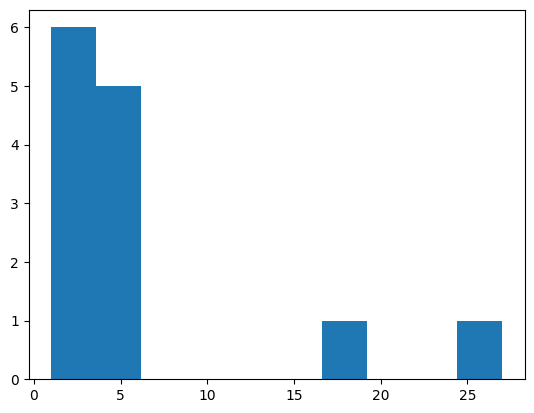

In [67]:
plt.hist(comp2["count_be_stars_pp13"])